In [4]:
%pip install matplotlib

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ----------------------------------- ---- 8.4/9.5 MB 41.8 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 32.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 35.1 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 41.9 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----------- -------------------

In [1]:
import sys
print(sys.executable)

c:\Users\alana\Documents\financial-services-complaints-project\.venv\Scripts\python.exe


In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator, StrMethodFormatter


In [3]:
complaints = pd.read_csv("../data/complaints.csv")

In [4]:
complaints.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2023-03-11T14:35:15.000Z,Mortgage,Other type of mortgage,Struggling to pay mortgage,NaN,Company has responded to the consumer and the ...,WELLS FARGO & COMPANY,FL,33541,NaN,Web,2023-03-11T14:42:35.000Z,Closed with explanation,Yes,6681446
1,2023-03-11T15:25:45.000Z,Mortgage,FHA mortgage,Trouble during payment process,NaN,Company believes complaint represents an oppor...,Mr. Cooper Group Inc.,MI,494XX,Servicemember,Web,2023-03-11T16:06:56.000Z,Closed with explanation,Yes,6681226
2,2023-03-11T15:59:06.000Z,Mortgage,FHA mortgage,Trouble during payment process,NaN,NaN,"EQUITY RESOURCES, INCORPORATED",OH,456XX,NaN,Web,2023-03-11T16:29:11.000Z,Closed with explanation,Yes,6681308
3,2023-03-11T16:35:15.000Z,Mortgage,FHA mortgage,Trouble during payment process,NaN,NaN,Mr. Cooper Group Inc.,NY,11580,NaN,Web,2023-03-11T16:55:49.000Z,Closed with explanation,Yes,6681193
4,2023-03-11T16:39:57.000Z,Mortgage,Conventional home mortgage,Trouble during payment process,NaN,Company has responded to the consumer and the ...,Specialized Loan Servicing Holdings LLC,VA,24127,Servicemember,Web,2023-03-11T17:23:24.000Z,Closed with explanation,Yes,6681137


In [5]:
complaints.shape

(98933, 15)

In [6]:
complaints.info()

<class 'pandas.DataFrame'>
RangeIndex: 98933 entries, 0 to 98932
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Date received                 98933 non-null  str  
 1   Product                       98933 non-null  str  
 2   Sub-product                   98933 non-null  str  
 3   Issue                         98933 non-null  str  
 4   Sub-issue                     79170 non-null  str  
 5   Company public response       46415 non-null  str  
 6   Company                       98933 non-null  str  
 7   State                         98692 non-null  str  
 8   ZIP code                      98890 non-null  str  
 9   Tags                          28341 non-null  str  
 10  Submitted via                 98933 non-null  str  
 11  Date sent to company          98933 non-null  str  
 12  Company response to consumer  98932 non-null  str  
 13  Timely response?              98933 non-nu

In [9]:
complaints['Complaint ID'].nunique()

98933

In [10]:
complaints['Complaint ID'].duplicated().sum()

np.int64(0)

In [11]:
complaints.isna().sum().sort_values(ascending=False)

Tags                            70592
Company public response         52518
Sub-issue                       19763
State                             241
ZIP code                           43
Company response to consumer        1
Date received                       0
Company                             0
Issue                               0
Product                             0
Sub-product                         0
Submitted via                       0
Date sent to company                0
Timely response?                    0
Complaint ID                        0
dtype: int64

In [14]:
(
    complaints.isna()
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
)

Tags                            71.4
Company public response         53.1
Sub-issue                       20.0
State                            0.2
Product                          0.0
Sub-product                      0.0
Date received                    0.0
Company                          0.0
Issue                            0.0
ZIP code                         0.0
Submitted via                    0.0
Date sent to company             0.0
Company response to consumer     0.0
Timely response?                 0.0
Complaint ID                     0.0
dtype: float64

In [15]:
complaints['Complaint ID'].nunique()

98933

In [16]:
complaints['Complaint ID'].duplicated().sum()

np.int64(0)

In [17]:
complaints.isna().sum().sort_values(ascending=False)

Tags                            70592
Company public response         52518
Sub-issue                       19763
State                             241
ZIP code                           43
Company response to consumer        1
Date received                       0
Company                             0
Issue                               0
Product                             0
Sub-product                         0
Submitted via                       0
Date sent to company                0
Timely response?                    0
Complaint ID                        0
dtype: int64

In [7]:
complaints['Date received'] = pd.to_datetime(complaints['Date received'],errors='coerce')
complaints['Date sent to company'] = pd.to_datetime(complaints['Date sent to company'],errors='coerce')

In [8]:
complaints[['Date received', 'Date sent to company']].isna().sum()

Date received           0
Date sent to company    0
dtype: int64

In [9]:
complaints[['Date received', 'Date sent to company']].dtypes

Date received           datetime64[us, UTC]
Date sent to company    datetime64[us, UTC]
dtype: object

In [10]:
complaints['Product'].value_counts().head(10)

Product
Mortgage    98933
Name: count, dtype: int64

In [11]:
complaints['Issue'].value_counts().head(10)

Issue
Trouble during payment process                                                      50644
Struggling to pay mortgage                                                          25724
Applying for a mortgage or refinancing an existing mortgage                         10292
Closing on a mortgage                                                                7473
Incorrect information on your report                                                 2773
Problem with a company's investigation into an existing problem                      1275
Improper use of your report                                                           372
Problem with a credit reporting company's investigation into an existing problem      146
Credit monitoring or identity theft protection services                               124
Unable to get your credit report or credit score                                       66
Name: count, dtype: int64

In [12]:
complaints['Company'].value_counts().head(10)

Company
Shellpoint Partners, LLC             10072
WELLS FARGO & COMPANY                 7509
Mr. Cooper Group Inc.                 6871
Ocwen Financial Corporation           4463
Rocket Mortgage, LLC                  4404
Freedom Mortgage Company              4324
SELECT PORTFOLIO SERVICING, INC.      3765
PENNYMAC LOAN SERVICES, LLC.          2449
CARRINGTON MORTGAGE SERVICES, LLC     2379
Selene Holdings LLC                   2253
Name: count, dtype: int64

In [13]:
(
    complaints['Issue']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .head(10)

)

Issue
Trouble during payment process                                                      51.2
Struggling to pay mortgage                                                          26.0
Applying for a mortgage or refinancing an existing mortgage                         10.4
Closing on a mortgage                                                                7.6
Incorrect information on your report                                                 2.8
Problem with a company's investigation into an existing problem                      1.3
Improper use of your report                                                          0.4
Problem with a credit reporting company's investigation into an existing problem     0.1
Credit monitoring or identity theft protection services                              0.1
Unable to get your credit report or credit score                                     0.1
Name: proportion, dtype: float64

In [14]:
(
    complaints['Company']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .head(10)
)

Company
Shellpoint Partners, LLC             10.2
WELLS FARGO & COMPANY                 7.6
Mr. Cooper Group Inc.                 6.9
Ocwen Financial Corporation           4.5
Rocket Mortgage, LLC                  4.5
Freedom Mortgage Company              4.4
SELECT PORTFOLIO SERVICING, INC.      3.8
PENNYMAC LOAN SERVICES, LLC.          2.5
CARRINGTON MORTGAGE SERVICES, LLC     2.4
Selene Holdings LLC                   2.3
Name: proportion, dtype: float64

In [15]:
complaints['Date received'].min()

Timestamp('2022-10-01 00:06:38+0000', tz='UTC')

In [16]:
complaints['Date received'].max()

Timestamp('2026-09-30 16:08:27+0000', tz='UTC')

In [17]:
monthly_complaints = (
    complaints
    .groupby(pd.Grouper(key='Date received', freq='MS'))
    .size()
    .reset_index(name='complaint_count')

)

In [18]:
monthly_complaints.head()

,Date received,complaint_count
0,2022-10-01 00:00:00+00:00,1624
1,2022-11-01 00:00:00+00:00,1518
2,2022-12-01 00:00:00+00:00,1824
3,2023-01-01 00:00:00+00:00,2837
4,2023-02-01 00:00:00+00:00,2165


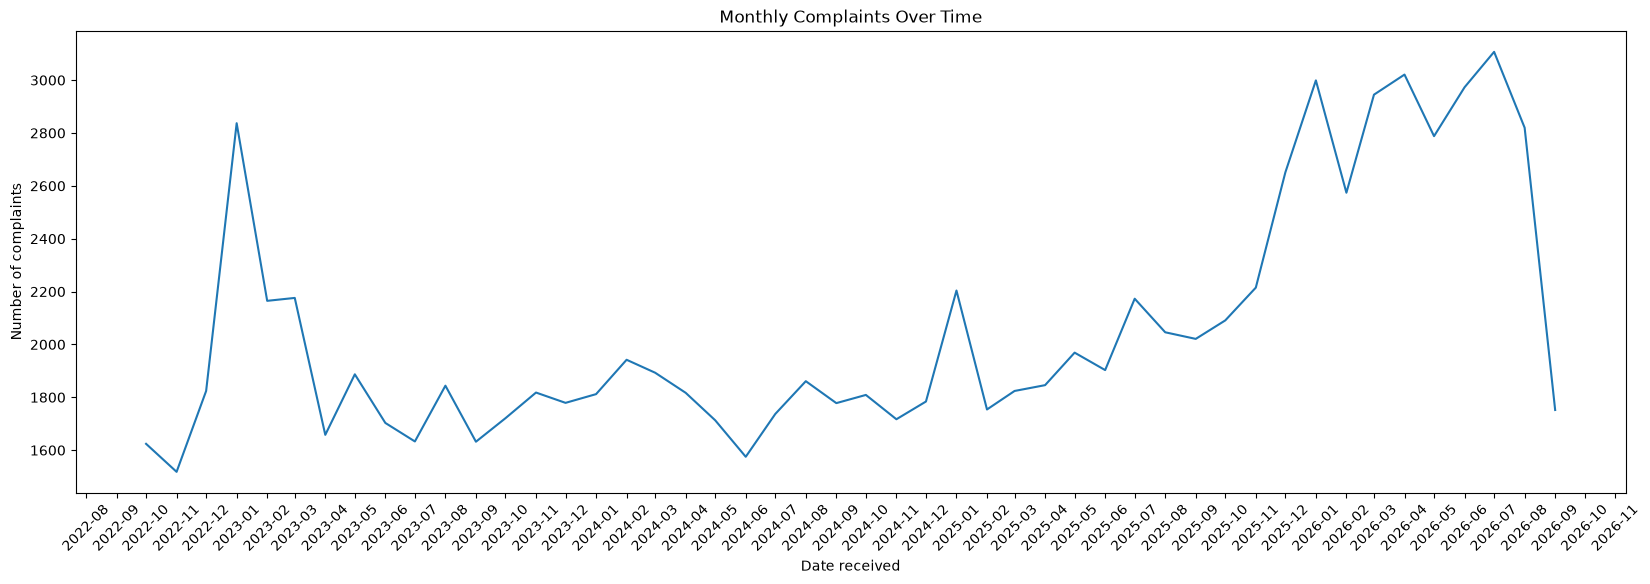

In [33]:
plt.figure(figsize=(20, 6))
plt.plot(monthly_complaints["Date received"], monthly_complaints["complaint_count"])
plt.xlabel("Date received")
plt.ylabel("Number of complaints")
plt.title("Monthly Complaints Over Time")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.show()

In [59]:
issues = (complaints['Issue'].value_counts().reset_index())
issues = issues.rename(columns={'count': 'complaint_count'})
issues['percent'] = issues['complaint_count'].div(issues['complaint_count'].sum()).mul(100).round(1)
print(issues.head(10))

                                               Issue  complaint_count  percent
0                     Trouble during payment process            50644     51.2
1                         Struggling to pay mortgage            25724     26.0
2  Applying for a mortgage or refinancing an exis...            10292     10.4
3                              Closing on a mortgage             7473      7.6
4               Incorrect information on your report             2773      2.8
5  Problem with a company's investigation into an...             1275      1.3
6                        Improper use of your report              372      0.4
7  Problem with a credit reporting company's inve...              146      0.1
8  Credit monitoring or identity theft protection...              124      0.1
9   Unable to get your credit report or credit score               66      0.1


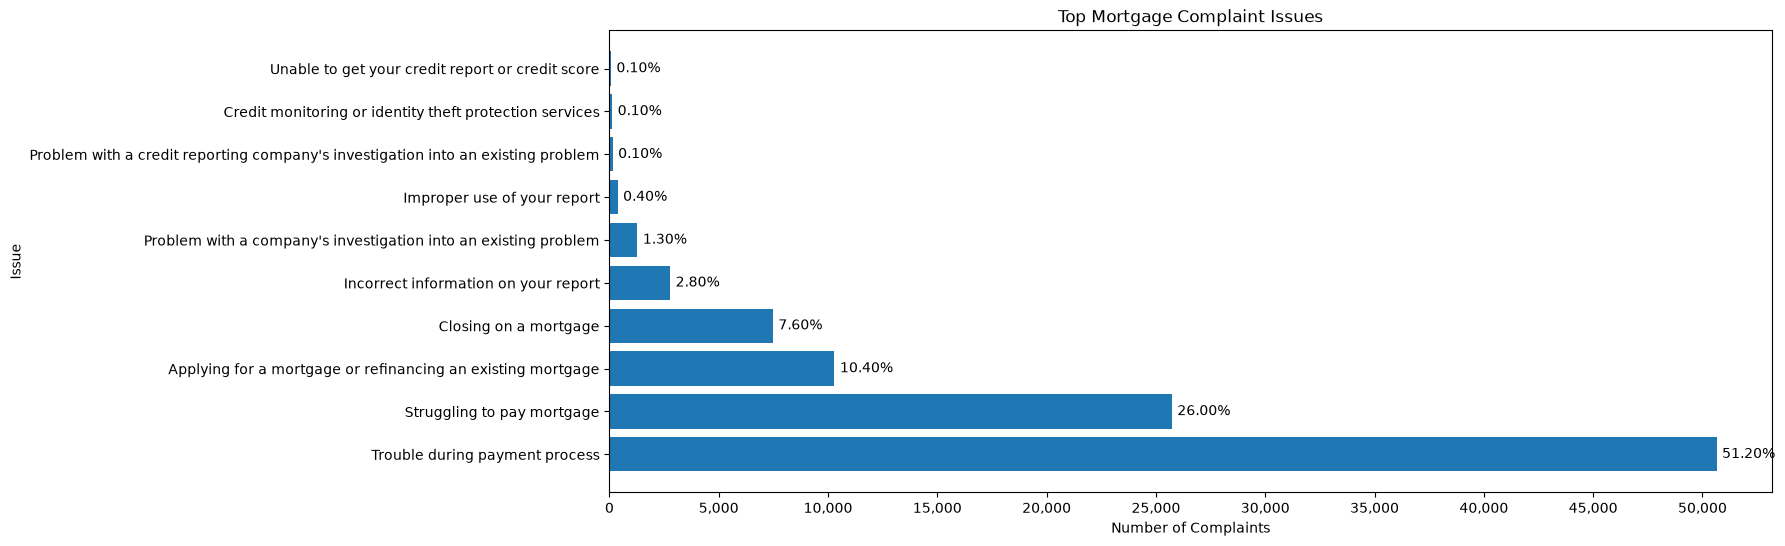

In [66]:
top_issues = issues.head(10)
plt.figure(figsize=(15, 6))
bars = plt.barh(top_issues["Issue"],top_issues["complaint_count"])
plt.bar_label(
    bars,
    labels=[f"{percent:.2f}%" for percent in top_issues["percent"]],
    padding=4
)
plt.title("Top Mortgage Complaint Issues")
plt.xlabel("Number of Complaints")
plt.ylabel("Issue")
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.gca().xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}")) # Format x-axis with commas
plt.show()

### Key Findings

- Over half of all mortgage complaints (51.2%) relate to **Trouble during payment process**, making it the most common issue in the dataset.
- “Struggling to pay mortgage” is the second-most common issue at 26.0%. Combined with payment-process complaints, this suggests that payment and servicing-related problems dominate the complaint population and warrant deeper analysis with additional mortgage-market data.
- The top five issue categories account for approximately 98% of all complaints, while the bottom five categories in the top-10 ranking represent only about 2%, indicating that complaints are highly concentrated in a small number of issue types.


In [98]:
condition = ((complaints['Issue'] == 'Trouble during payment process') | (complaints['Issue'] == 'Struggling to pay mortgage'))
monthly_issue_counts = complaints.loc[condition].groupby([pd.Grouper(key='Date received', freq='MS'), 'Issue']).size().reset_index(name='complaint_count')
monthly_issue_counts.head()

,Date received,Issue,complaint_count
0,2022-10-01 00:00:00+00:00,Struggling to pay mortgage,421
1,2022-10-01 00:00:00+00:00,Trouble during payment process,760
2,2022-11-01 00:00:00+00:00,Struggling to pay mortgage,363
3,2022-11-01 00:00:00+00:00,Trouble during payment process,813
4,2022-12-01 00:00:00+00:00,Struggling to pay mortgage,532


In [99]:
monthly_totals = monthly_complaints.rename(columns={"complaint_count": "total_complaints"})

In [92]:
monthly_issue_pivot = monthly_issue_counts.pivot(index='Date received', columns='Issue', values='complaint_count').fillna(0)
monthly_issue_pivot.head()

Issue,Struggling to pay mortgage,Trouble during payment process
Date received,,
2022-10-01 00:00:00+00:00,421,760
2022-11-01 00:00:00+00:00,363,813
2022-12-01 00:00:00+00:00,532,906
2023-01-01 00:00:00+00:00,988,1224
2023-02-01 00:00:00+00:00,588,1118


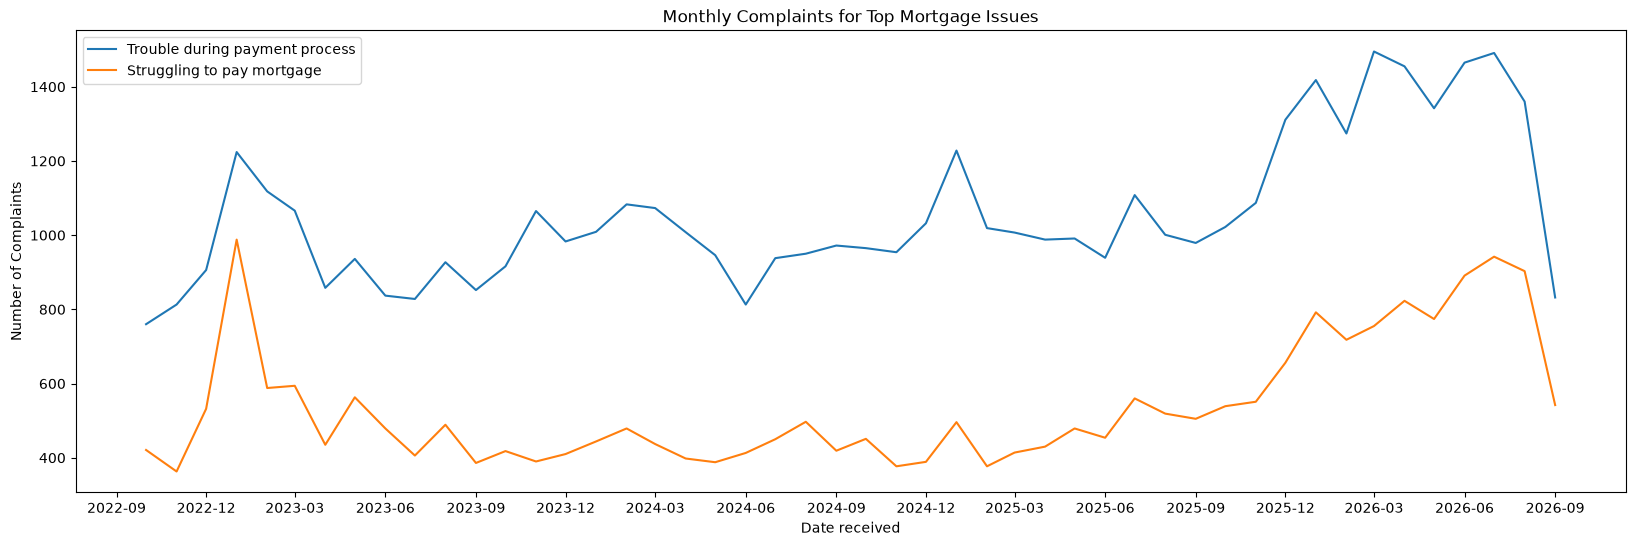

In [93]:
plt.figure(figsize=(20, 6))
plt.plot(monthly_issue_pivot.index, monthly_issue_pivot['Trouble during payment process'], label='Trouble during payment process')
plt.plot(monthly_issue_pivot.index, monthly_issue_pivot['Struggling to pay mortgage'], label='Struggling to pay mortgage')
plt.legend()
plt.title("Monthly Complaints for Top Mortgage Issues")
plt.xlabel("Date received")
plt.ylabel("Number of Complaints")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.show()

In [ ]:
monthly_issue_counts = monthly_issue_counts.merge(monthly_totals, on='Date received', how='left')
monthly_issue_counts["issue_percent"] = (monthly_issue_counts["complaint_count"] / monthly_issue_counts["total_complaints"] * 100).round(2)
monthly_issue_counts.head()

,Date received,Issue,complaint_count,total_complaints,issue_percent
0,2022-10-01 00:00:00+00:00,Struggling to pay mortgage,421,1624,25.92
1,2022-10-01 00:00:00+00:00,Trouble during payment process,760,1624,46.80
2,2022-11-01 00:00:00+00:00,Struggling to pay mortgage,363,1518,23.91
3,2022-11-01 00:00:00+00:00,Trouble during payment process,813,1518,53.56
4,2022-12-01 00:00:00+00:00,Struggling to pay mortgage,532,1824,29.17


In [102]:
monthly_issue_percent_pivot = monthly_issue_counts.pivot(index='Date received', columns='Issue', values='issue_percent').fillna(0)
monthly_issue_percent_pivot.head()

Issue,Struggling to pay mortgage,Trouble during payment process
Date received,,
2022-10-01 00:00:00+00:00,25.92,46.80
2022-11-01 00:00:00+00:00,23.91,53.56
2022-12-01 00:00:00+00:00,29.17,49.67
2023-01-01 00:00:00+00:00,34.83,43.14
2023-02-01 00:00:00+00:00,27.16,51.64


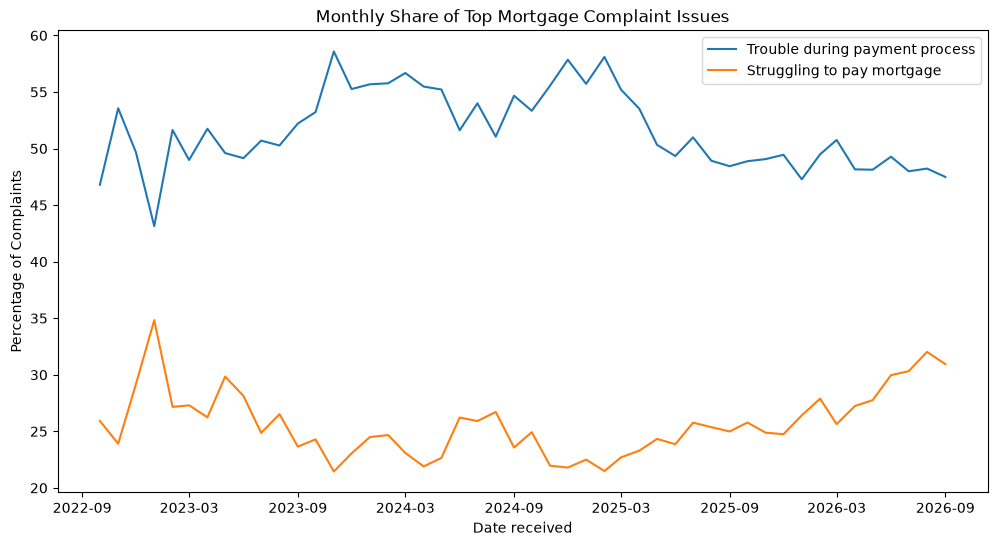

In [104]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_issue_percent_pivot.index, monthly_issue_percent_pivot['Trouble during payment process'], label='Trouble during payment process')
plt.plot(monthly_issue_percent_pivot.index, monthly_issue_percent_pivot['Struggling to pay mortgage'], label='Struggling to pay mortgage')
plt.title("Monthly Share of Top Mortgage Complaint Issues")
plt.xlabel("Date received")
plt.ylabel("Percentage of Complaints")
plt.legend()
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.show()


### Key Findings
- Although “Trouble during payment process” increased in raw complaint volume during 2025–2026, its share of total monthly complaints declined from peaks in the mid-to-high 50% range to roughly the high-40% range by 2026.
- “Struggling to pay mortgage” showed the opposite pattern. Its share of monthly complaints rose from mostly the low-to-mid 20% range to roughly 30% or more by 2026.
- This suggests that the overall increase in mortgage complaint volume was accompanied by a shift in complaint mix, with payment-affordability concerns becoming relatively more prominent over time. This trend warrants further analysis alongside mortgage-rate and ARM-related data.